importation des bibliotech 

le chargement de data en fromat de csv

In [87]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt


In [88]:
df = pd.read_csv("../data/row/car-price.csv")

print(df.head())
print("=======================================")
print(df.shape)

                        name    year  selling_price  km_driven    fuel  \
0              Maruti 800 AC  2007.0          60000    70000.0  Petrol   
1       Hyundai Verna 1.6 SX  2012.0         600000   100000.0  Diesel   
2     Datsun RediGO T Option  2017.0         250000    46000.0  Petrol   
3       Maruti Alto LX BSIII  2007.0         140000   125000.0  Petrol   
4  Hyundai Xcent 1.2 Kappa S  2016.0         550000    25000.0  Petrol   

  seller_type transmission        owner  
0  Individual       Manual  First Owner  
1  Individual       Manual  First Owner  
2  Individual       Manual  First Owner  
3  Individual       Manual  First Owner  
4  Individual       Manual  First Owner  
(4340, 8)


les info sur les donnes ariver dans csv

In [89]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4340 non-null   object 
 1   year           4297 non-null   float64
 2   selling_price  4340 non-null   int64  
 3   km_driven      4167 non-null   float64
 4   fuel           4254 non-null   object 
 5   seller_type    4275 non-null   object 
 6   transmission   4340 non-null   object 
 7   owner          4254 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 271.4+ KB
None


les columns quand a dans la dataframe 

In [90]:
print(df.columns)

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')


Analyse statistique avec describe

In [91]:
print(df.describe())

              year  selling_price      km_driven
count  4297.000000   4.340000e+03    4167.000000
mean   2013.087736   5.041273e+05   66237.198224
std       4.219918   5.785487e+05   46635.456187
min    1992.000000   2.000000e+04       1.000000
25%    2011.000000   2.087498e+05   35000.000000
50%    2014.000000   3.500000e+05   60000.000000
75%    2016.000000   6.000000e+05   90000.000000
max    2020.000000   8.900000e+06  806599.000000


definir la valeur qui doit predict le model 

In [92]:
input_data = df.drop("selling_price",axis=1)
output_data = df["selling_price"]


In [93]:
df["fuel"].value_counts()

fuel
Diesel      2116
Petrol      2077
CNG           38
LPG           22
Electric       1
Name: count, dtype: int64

In [94]:
df["seller_type"].value_counts()

seller_type
Individual          3198
Dealer               976
Trustmark Dealer     101
Name: count, dtype: int64

In [95]:
df["transmission"].value_counts()

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

In [96]:
df["owner"].value_counts()

owner
First Owner             2771
Second Owner            1084
Third Owner              302
Fourth & Above Owner      80
Test Drive Car            17
Name: count, dtype: int64

In [97]:
df.isnull().sum()

name               0
year              43
selling_price      0
km_driven        173
fuel              86
seller_type       65
transmission       0
owner             86
dtype: int64

In [98]:
# print( df["km_driven"].median())

df["km_driven"] = df["km_driven"].fillna(
    df["km_driven"].median()
)

df["year"] = df["year"].fillna(
    df["year"].median()
)

df["fuel"] = df["fuel"].fillna(
    df["fuel"].mode()[0]
)
df["seller_type"] = df["seller_type"].fillna(
    df["seller_type"].mode()[0]
)
df["owner"] = df["owner"].fillna(
    df["owner"].mode()[0]
)


In [99]:
# df.duplicated().sum()

df = df.drop_duplicates()
df.shape



(3672, 8)

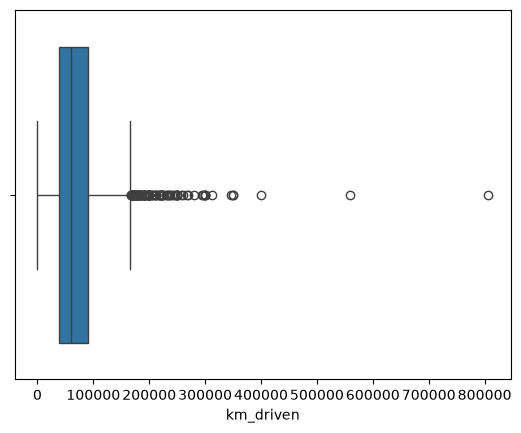

In [100]:
sns.boxplot(x=df["km_driven"])
plt.show()

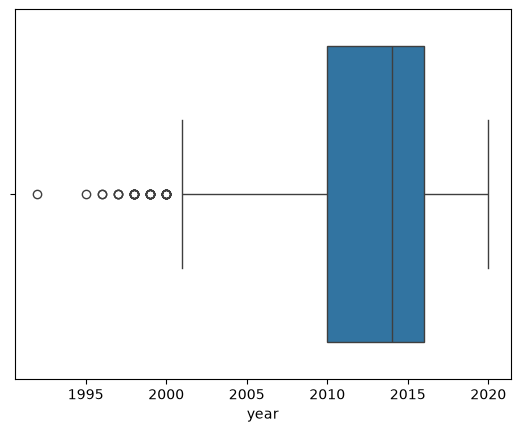

In [101]:
sns.boxplot(x=df["year"])
plt.show()

outlier de kilometrage 


In [104]:
Q1_km = df["km_driven"].quantile(0.25)
Q3_km = df["km_driven"].quantile(0.75)

demi = Q3_km - Q1_km

lower = Q1_km - demi
upper = Q3_km + demi

out = df[
    (df["km_driven"] < lower) |
    (df["km_driven"] > upper)
]

df = df.drop(out)
# print(out)
# print(Q1)
# print(Q3)

print(df)

KeyError: "['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner'] not found in axis"

outlier de age 

In [ ]:
Q1_year = df["year"].quantile(0.25)
Q3_year = df["year"].quantile(0.75)

demi_2 = Q3_year - Q1_year

upper_2 = Q3_year + demi_2
lower_2 = Q1_year - demi_2


out_2 = df[
    (df["year"] < lower_2) |
    (df["year"] > upper_2)
]

df = df.drop(out_2)

print(df)   

outlier de prix


In [ ]:
Q1_price = df["year"].quantile(0.25)
Q3_price = df["year"].quantile(0.75)

demi_3 = Q3_price - Q1_price

upper_3 = Q3_price + demi_3
lower_3 = Q1_price - demi_3


out_3 = df[
    (df["year"] < lower_3) |
    (df["year"] > upper_3)
]

df = df.drop(out_3)

print(df)   